In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Lectura de parámetros desde config.xlsx
config = pd.read_excel(os.path.join(BASE_PATH, "NOTEBOOKS", "config.xlsx"), sheet_name="config", index_col="parameter")["value"]
min_k_clusters = int(config["min_k_clusters"])
max_k_clusters = int(config["max_k_clusters"])
k_final = int(config["k_final"])

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

print(f"Rango de clusters: {min_k_clusters} a {max_k_clusters}")
print(f"k_final: {k_final}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline
Rango de clusters: 2 a 8
k_final: 2


Primero se aplican técnicas de aprendizaje no supervisado para definir el clasificador y dividir las ventanas.

Después se hará todo el proceso para construir un modelo que prediga esa clasificación en función de las variables.

Clustering se define como agrupar puntos usando una distancia, de forma que los puntos dentro de un mismo grupo sean parecidos y los puntos de grupos distintos sean diferentes.

Número de clústers = k

Si k=2 quiere decir que se van a clasificar los datos en dos grupos, por ejemplo grupo0 = "poco oleaje" y grupo1= "mucho oleaje".

Un centroide es el centro de un grupo.

* Ventana A: Oleaje 0.4, Mod_orbital 0.05
* Ventana B: Oleaje 0.6, Mod_orbital 0.07
* Ventana C: Oleaje 0.5, Mod_orbital 0.06

El centroide sería algo parecido a:

* Oleaje medio = 0.5
* Mod_orbital medio = 0.06

Es decir, el centroide representa el “promedio” del grupo.

Por eso K-Means funciona bien con variables numéricas continuas, porque está basado en distancias euclídeas y centroides.

# CARGA DE DATOS

In [2]:
base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df_oleaje = pd.read_csv(os.path.join(base_path, "df_wave.csv"))
df_features = pd.read_csv(os.path.join(base_path, "df_features.csv"))

df = pd.merge(
    df_oleaje,
    df_features,
    on="window_id",
    how="inner"
)

df_oleaje.head()

,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vz,mean_O2,...,flux_smooth,flag_outlier_global,flag_outlier_window,flag_flux_positivo,flag_vz_baja,Oleaje,Mod_orbital,STD_orbital,hour_int,Oleaje_SIMAR
0,0,13.12,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-0.000940,219.341074,...,-6.351335,False,False,False,False,9.664,0.015203,0.009969,13,1.87
1,1,13.37,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-0.001864,220.214211,...,-6.745481,False,False,False,False,9.876,0.015946,0.010475,13,1.87
2,2,13.62,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-0.001838,220.537457,...,-6.619435,False,False,False,False,9.004,0.013689,0.008438,13,1.87
3,3,13.87,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.001537,220.398051,...,-6.799723,False,False,False,False,8.556,0.012808,0.008059,13,1.87
4,4,14.12,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.001444,220.429227,...,-6.911006,False,False,False,False,9.500,0.013456,0.007926,14,1.86


# IMPLEMENTACIÓN K-MEANS

In [3]:
# Variables comunes de presión
pres_features = [
    "pres__mean",
    "pres__standard_deviation",
    "pres__median",
]

# Definición de escenarios
escenarios = {
    "Wiberg": {
        "features": ["Oleaje", "Mod_orbital", "STD_orbital"] + pres_features,
        "col_oleaje": "Oleaje",
    },
    "SIMAR": {
        "features": ["Oleaje_SIMAR"] + pres_features,
        "col_oleaje": "Oleaje_SIMAR",
    },
}

for nombre, esc in escenarios.items():
    print(f"{nombre}: {esc['features']}")

Wiberg: ['Oleaje', 'Mod_orbital', 'STD_orbital', 'pres__mean', 'pres__standard_deviation', 'pres__median']
SIMAR: ['Oleaje_SIMAR', 'pres__mean', 'pres__standard_deviation', 'pres__median']


In [4]:
# Preprocesado para cada escenario
X_scaled_dict = {}

for nombre, esc in escenarios.items():
    X = df[esc["features"]].copy()
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_scaled_dict[nombre] = scaler.fit_transform(imputer.fit_transform(X))
    print(f"{nombre}: {X_scaled_dict[nombre].shape}")

Wiberg: (660, 6)
SIMAR: (660, 4)


# EVALUACIÓN DE NÚMERO DE CLÚSTERS

In [5]:
# Evaluación de k para cada escenario
k_values = range(min_k_clusters, max_k_clusters + 1)
resultados_k = {}

for nombre, X_scaled in X_scaled_dict.items():
    inertias = []
    silhouettes = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_scaled)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    resultados_k[nombre] = pd.DataFrame({
        "k": list(k_values),
        "inertia": inertias,
        "silhouette": silhouettes,
    })

    print(f"\n=== {nombre} ===")
    display(resultados_k[nombre])


=== Wiberg ===


,k,inertia,silhouette
0,2,2152.374106,0.395311
1,3,1492.592996,0.389897
2,4,1120.435527,0.381077
3,5,879.555746,0.385002
4,6,735.428295,0.384184
5,7,656.779782,0.394414
6,8,579.382102,0.393248



=== SIMAR ===


,k,inertia,silhouette
0,2,1652.196924,0.344015
1,3,1060.540024,0.371905
2,4,710.187861,0.418175
3,5,589.570606,0.415600
4,6,490.297288,0.390507
5,7,421.853956,0.388477
6,8,365.848095,0.372361


Para seleccionar el número de grupos en KMeans se evaluaron dos criterios: el método del codo y el coeficiente silhouette.

En primer lugar, el método del codo analiza la inercia del modelo para distintos valores de k. La inercia representa la suma de las distancias de cada punto al centroide de su cluster, por lo que valores más bajos indican grupos más compactos. Como es esperable, la inercia disminuye al aumentar el número de clusters, ya que el modelo dispone de más centroides para ajustar los datos. En la gráfica se observa una reducción importante de la inercia entre k = 2 y k = 4. A partir de k = 4, la disminución continúa, pero de forma más suave. Esto sugiere que alrededor de k = 4 aparece un posible “codo”, es decir, un punto a partir del cual añadir más clusters aporta una mejora menor en la compactación de los grupos.

En segundo lugar, se calculó el silhouette score, que evalúa simultáneamente la cohesión interna de los clusters y la separación entre clusters. Este índice toma valores más altos cuando los puntos están bien asignados a su propio grupo y suficientemente separados de los demás.

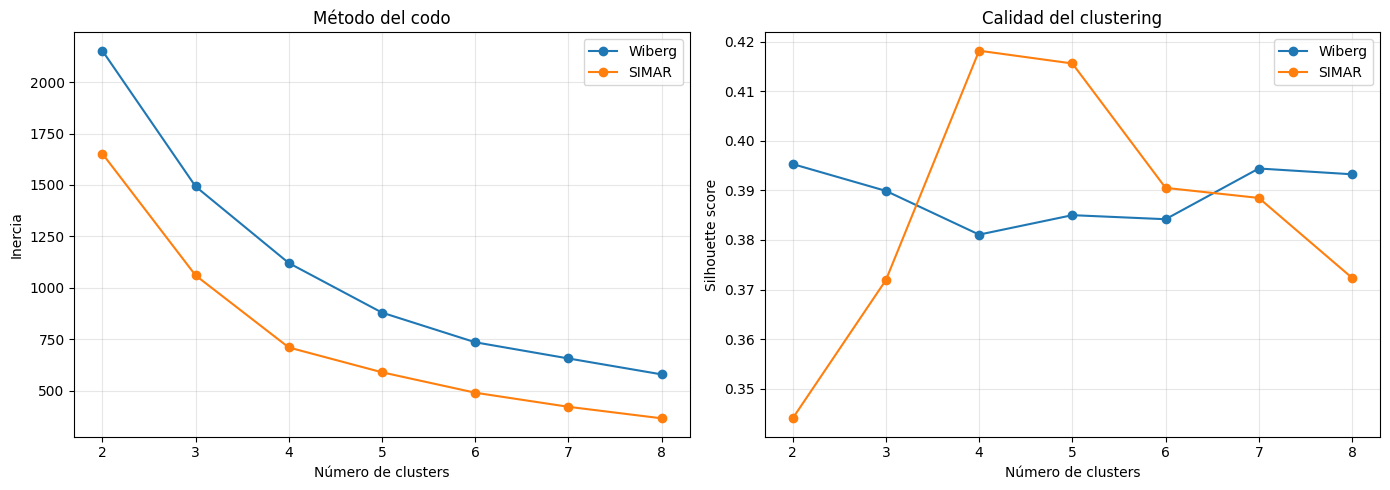

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, df_k in resultados_k.items():
    axes[0].plot(df_k["k"], df_k["inertia"], marker="o", label=nombre)
    axes[1].plot(df_k["k"], df_k["silhouette"], marker="o", label=nombre)

axes[0].set_xlabel("Número de clusters")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Número de clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Calidad del clustering")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# APLICACIÓN FINAL DE K-MEANS

In [7]:
# Aplicar K-Means con k_final a cada escenario
if k_final == 2:
    nombres_clase = {0: "poco_oleaje", 1: "mucho_oleaje"}
else:
    nombres_clase = {i: f"clase_{i}" for i in range(k_final)}

for nombre, esc in escenarios.items():
    X_scaled = X_scaled_dict[nombre]
    col_oleaje = esc["col_oleaje"]

    kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
    labels_raw = kmeans.fit_predict(X_scaled)

    # Reordenar clusters por oleaje medio ascendente
    df_tmp = df[[col_oleaje]].copy()
    df_tmp["label"] = labels_raw
    orden = df_tmp.groupby("label")[col_oleaje].mean().sort_values().index.tolist()
    mapa = {orig: nuevo for nuevo, orig in enumerate(orden)}
    labels_sorted = np.array([mapa[l] for l in labels_raw])

    # Guardar en columnas separadas
    col_clase = f"oleaje_clase_{nombre}"
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    df[col_clase] = labels_sorted
    df[col_nombre_clase] = df[col_clase].map(nombres_clase)

    sil = silhouette_score(X_scaled, labels_sorted)
    print(f"\n=== {nombre} (k={k_final}) ===")
    print(f"  Silhouette: {sil:.4f}")
    print(f"  Distribución: {dict(pd.Series(labels_sorted).value_counts().sort_index())}")


=== Wiberg (k=2) ===
  Silhouette: 0.3953
  Distribución: {0: np.int64(306), 1: np.int64(354)}

=== SIMAR (k=2) ===
  Silhouette: 0.3440
  Distribución: {0: np.int64(326), 1: np.int64(334)}


In [8]:
# Resumen por clase para cada escenario
for nombre, esc in escenarios.items():
    col_clase = f"oleaje_clase_{nombre}"
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    print(f"\n{'='*60}")
    print(f"RESUMEN — {nombre}")
    print(f"{'='*60}")
    display(
        df.groupby([col_clase, col_nombre_clase])[esc["features"]]
        .agg(["count", "mean", "std", "median"])
        .round(4)
    )


RESUMEN — Wiberg


Oleaje                   \
                                                count     mean     std   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   poco_oleaje                   284  12.8044  4.0600   
1                   mucho_oleaje                  266  28.3818  5.1571   

                                                       Mod_orbital          \
                                                median       count    mean   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                               
0                   poco_oleaje                 10.230         306  0.0212   
1                   mucho_oleaje                27.554         354  0.0530   

                                                               STD_orbital  \
                                                   std  median       count   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                               
0                   poco_oleaje                 0.0084  0.0162         306   
1                   mucho_oleaje                0.0103  0.0510         354   

                                                        ... pres__mean  \
                                                  mean  ...        std   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre          ...              
0                   poco_oleaje                 0.0138  ...    78.9648   
1                   mucho_oleaje                0.0354  ...    58.6866   

                                                           \
                                                   median   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre              
0                   poco_oleaje                 1530.5032   
1                   mucho_oleaje                1544.9394   

                                               pres__standard_deviation  \
                                                                  count   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                            
0                   poco_oleaje                                     306   
1                   mucho_oleaje                                    354   

                                                                        \
                                                  mean     std  median   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   poco_oleaje                 4.3755  1.0310  4.4672   
1                   mucho_oleaje                7.6435  1.2875  7.4282   

                                               pres__median             \
                                                      count       mean   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   poco_oleaje                         306  1536.7511   
1                   mucho_oleaje                        354  1539.9410   

                                                                  
                                                    std   median  
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                    
0                   poco_oleaje                 78.9800  1530.15  
1                   mucho_oleaje                58.6972  1544.95  

[2 rows x 24 columns]


RESUMEN — SIMAR


Oleaje_SIMAR                  \
                                                    count    mean     std   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  poco_oleaje                        326  3.3487  1.2200   
1                  mucho_oleaje                       334  3.3691  1.2823   

                                                    pres__mean             \
                                             median      count       mean   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  poco_oleaje                 3.77        326  1478.2521   
1                  mucho_oleaje                3.83        334  1597.1965   

                                                                  \
                                                  std     median   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                       
0                  poco_oleaje                35.1988  1482.4890   
1                  mucho_oleaje               33.8918  1594.5904   

                                             pres__standard_deviation          \
                                                                count    mean   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                    
0                  poco_oleaje                                    326  6.1214   
1                  mucho_oleaje                                   334  6.1351   

                                                             pres__median  \
                                                 std  median        count   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  poco_oleaje                2.0143  6.0345          326   
1                  mucho_oleaje               2.0086  6.1309          334   

                                                                          
                                                   mean      std  median  
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                              
0                  poco_oleaje                1478.2559  35.2278  1482.2  
1                  mucho_oleaje               1597.2261  33.8717  1594.6

# COMPROBACIONES

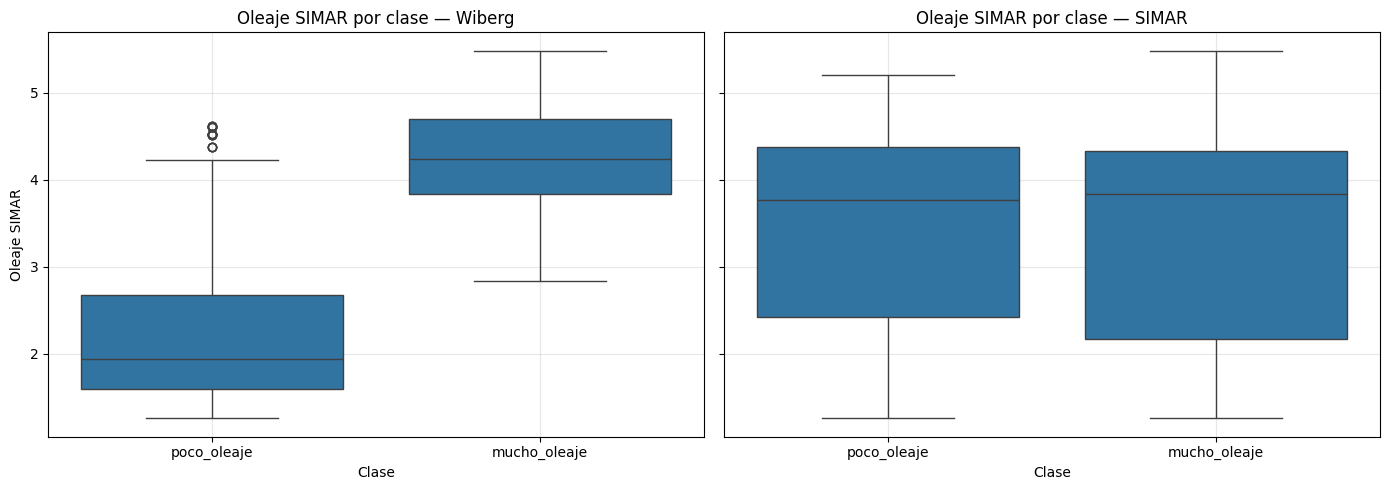

In [9]:
# Comprobación: Oleaje SIMAR por clase (ambos escenarios)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, nombre in enumerate(escenarios.keys()):
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    sns.boxplot(data=df, x=col_nombre_clase, y="Oleaje_SIMAR", ax=axes[i])
    axes[i].set_title(f"Oleaje SIMAR por clase — {nombre}")
    axes[i].set_xlabel("Clase")
    axes[i].set_ylabel("Oleaje SIMAR" if i == 0 else "")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

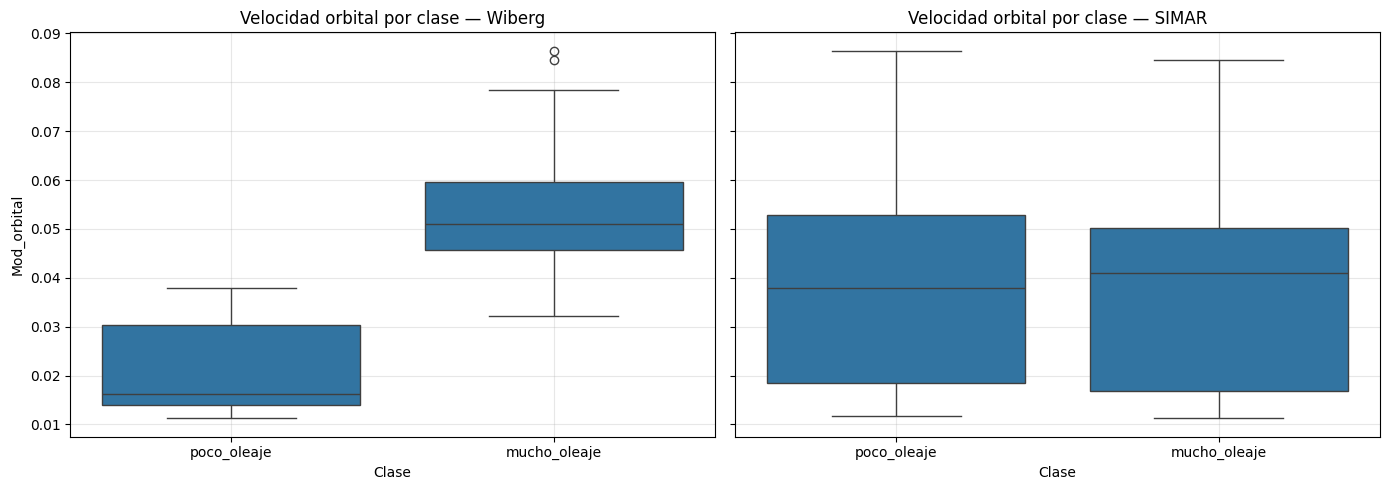

In [10]:
# Comprobación: Mod_orbital por clase (ambos escenarios)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, nombre in enumerate(escenarios.keys()):
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    sns.boxplot(data=df, x=col_nombre_clase, y="Mod_orbital", ax=axes[i])
    axes[i].set_title(f"Velocidad orbital por clase — {nombre}")
    axes[i].set_xlabel("Clase")
    axes[i].set_ylabel("Mod_orbital" if i == 0 else "")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

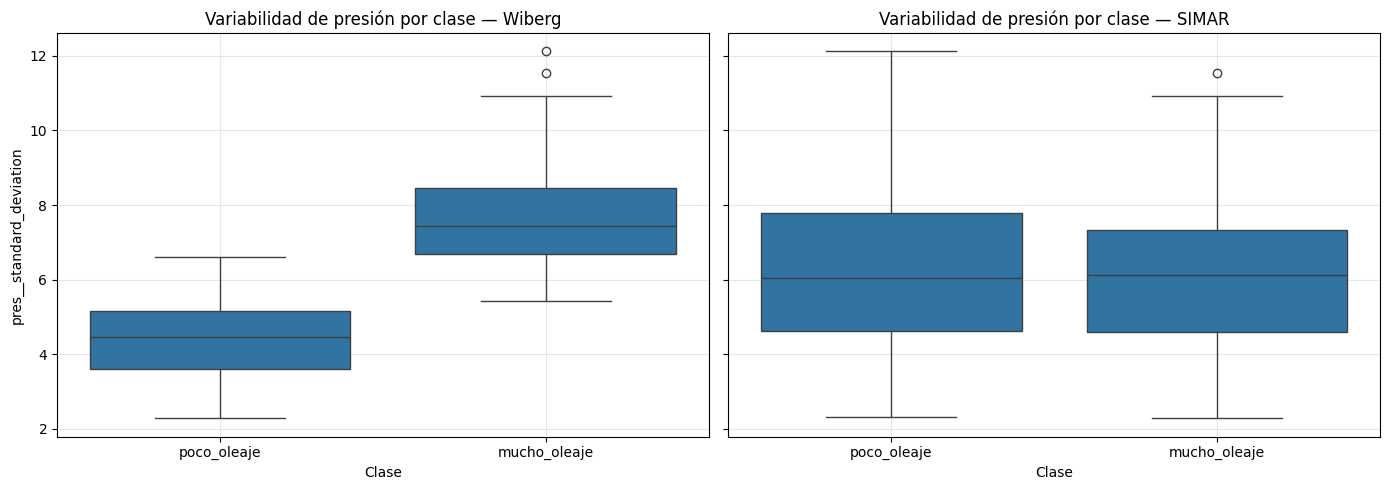

In [11]:
# Comprobación: variabilidad de presión por clase (ambos escenarios)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, nombre in enumerate(escenarios.keys()):
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    sns.boxplot(data=df, x=col_nombre_clase, y="pres__standard_deviation", ax=axes[i])
    axes[i].set_title(f"Variabilidad de presión por clase — {nombre}")
    axes[i].set_xlabel("Clase")
    axes[i].set_ylabel("pres__standard_deviation" if i == 0 else "")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CREACIÓN DE FICHEROS CON LOS DATOS CLASIFICADOS

In [12]:
# Columnas de clasificación generadas
cols_clase = [c for c in df.columns if c.startswith("oleaje_clase_")]
print("Columnas de clasificación guardadas:")
print(cols_clase)

output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_classified.csv")
df.to_csv(output_path, index=False)
print(f"\nDatos guardados en: {output_path}")

Columnas de clasificación guardadas:
['oleaje_clase_Wiberg', 'oleaje_clase_Wiberg_nombre', 'oleaje_clase_SIMAR', 'oleaje_clase_SIMAR_nombre']

Datos guardados en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline\DATA\PROCESSED\df_classified.csv
